In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


patients_path = '/media/Volume/data/MIMIC_IV/patients.csv.gz'
discharge_path = '/media/Volume/data/MIMIC_IV/discharge.csv.gz'
admissions_path = '/media/Volume/data/MIMIC_IV/admissions.csv.gz'
exams_path = '/media/Volume/data/MIMIC_IV/exams_filtered.csv'
out_path = '/media/Volume/data/MIMIC_IV/exams_cox_labels.csv'
icu_stays_path = '/media/Volume/data/MIMIC_IV/icustays.csv.gz'
dat_path = '/media/Volume/data/MIMIC_IV/record_list.csv'
machine_measurement_path = '/media/Volume/data/MIMIC_IV/machine_measurements.csv'
notes_path = '/media/Volume/data/MIMIC_IV/waveform_note_links.csv'

code_15_exams = '/media/Volume/data/CODE15/processed/exams_filtered.csv'

In [2]:
dat = pd.read_csv(dat_path)
dat

,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569
...,...,...,...,...,...
800030,19999840,48683947,48683947,2164-09-12 12:28:00,files/p1999/p19999840/s48683947/48683947
800031,19999840,41842293,41842293,2164-09-17 11:31:00,files/p1999/p19999840/s41842293/41842293
800032,19999987,41190887,41190887,2145-11-02 19:54:00,files/p1999/p19999987/s41190887/41190887
800033,19999987,45828463,45828463,2145-11-03 03:00:00,files/p1999/p19999987/s45828463/45828463


Nan detected:  3630


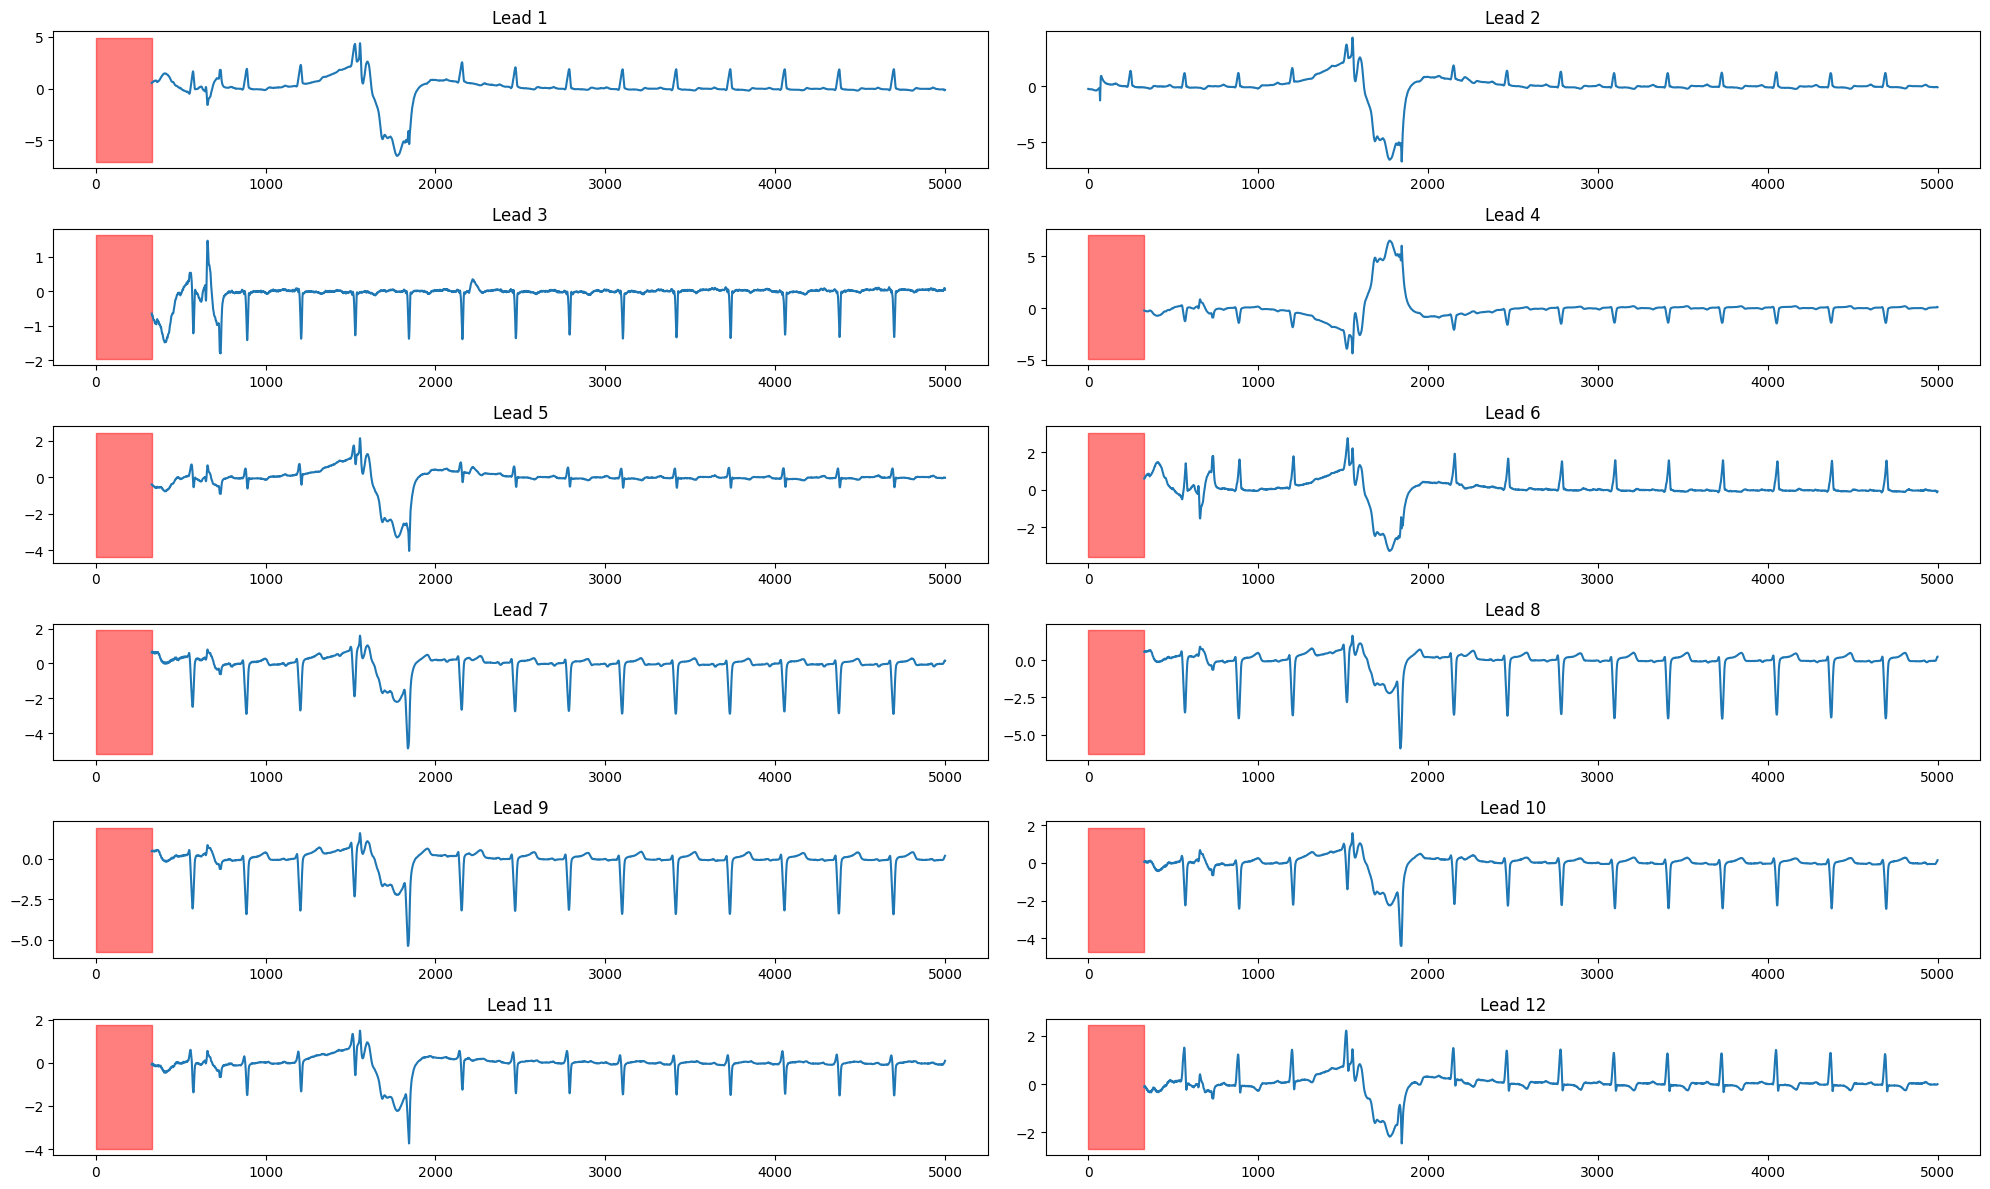

In [3]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

file_name = 'files/p1056/p10569454/s42081370/42081370'
signal, info = wfdb.rdsamp('/media/Volume/data/MIMIC_IV/' + file_name)
fig, axs = plt.subplots(6, 2, figsize=(20, 12))
leads = signal.shape[1]
print('Nan detected: ', np.sum(np.isnan(signal)))
# fillna
#signal = np.nan_to_num(signal)

for i in range(leads):
    ax = axs[i // 2, i % 2]
    sig = signal[:, i]

    ax.plot(sig)

    # Find NaNs and highlight them
    nan_mask = np.isnan(sig)
    ax.fill_between(np.arange(len(sig)), ax.get_ylim()[0], ax.get_ylim()[1], where=nan_mask, color="red", alpha=0.5)

    ax.set_title(f'Lead {i+1}')

plt.tight_layout()
plt.show()

In [4]:
code_15 = pd.read_csv(code_15_exams)
# drop unnamed 0 and unnamed 1
code_15 = code_15.loc[:, ~code_15.columns.str.contains('^Unnamed')]
# print columns
print(code_15.columns)
# remove null timey and death
code_15 = code_15[code_15['timey'].notna()]
code_15.head(n=10)

Index(['exam_id', 'age', 'is_male', 'nn_predicted_age', '1dAVb', 'RBBB',
       'LBBB', 'SB', 'ST', 'AF', 'patient_id', 'death', 'timey', 'normal_ecg',
       'trace_file', 'r_peaks', 'r_peak_interval_mean', 'r_peak_variance',
       'valid'],
      dtype='object')


,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file,r_peaks,r_peak_interval_mean,r_peak_variance,valid
0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5,[ 57 285 507 742 972 1196 1419 1630 1848 ...,0.625309,0.020557,True
1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5,[ 219 460 702 944 1176 1404 1631 1859 2080],0.646181,0.020969,True
2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5,[ 220 532 716 1024 1200 1599 1874],0.765741,0.214907,True
3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5,[ 306 585 868 1142 1434 1725 2004 2290 2595 ...,0.795679,0.024149,True
4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5,[ 115 285 454 623 793 962 1132 1303 1474 ...,0.473090,0.002729,True
6,1467619,33,False,48.628563,False,False,False,False,False,False,1351337,False,1.498629,False,exams_part13.hdf5,[ 271 623 969 1303 1629 1971 2313 2660],0.948016,0.022455,True
7,1537328,24,True,29.179337,False,False,False,False,False,False,1519774,False,1.367122,True,exams_part13.hdf5,[ 224 465 702 985 1259 1497 1744 2012 2269 ...,0.692222,0.054459,True
8,981735,82,True,82.224610,False,False,False,False,False,False,1192754,False,2.468491,False,exams_part13.hdf5,[ 160 432 684 925 1152 1377 1604 1838 2108 ...,0.716111,0.097054,True
10,1237983,81,False,80.735916,False,False,False,False,False,False,485601,False,1.978081,False,exams_part13.hdf5,[ 123 356 587 820 1054 1283 1512 1744 1976],0.643403,0.004799,True
11,2854912,63,True,41.023660,False,False,False,False,False,False,1594408,False,5.778077,False,exams_part13.hdf5,[ 93 454 822 1020],0.858333,0.218169,True


/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/lifelines/utils/__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


<Axes: xlabel='timeline'>

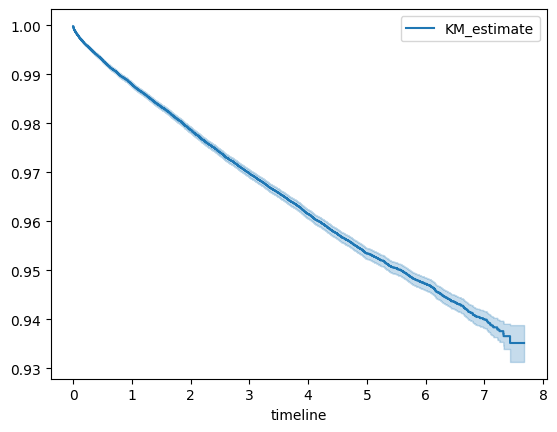

In [8]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(durations=code_15['timey'], event_observed=code_15['death'])
kmf.plot_survival_function()

In [31]:
pct_survival = kmf.survival_function_[(kmf.survival_function_.index <= 5.001) & (kmf.survival_function_.index >= 4.999)].values[0][0]
print(f'Percentage survival at 5 years: {pct_survival*100:.2f}%')
print(f'Percentage mortality at 5 years: {(1-pct_survival)*100:.2f}%')

Percentage survival at 5 years: 95.34%
Percentage mortality at 5 years: 4.66%


In [32]:
import os
from datetime import timedelta
data_folder = '/media/Volume/data/MIMIC_IV'

machine_measurement_path = os.path.join(data_folder, 'machine_measurements.csv')
if not os.path.exists(machine_measurement_path):
    raise FileNotFoundError(f"MIMIC-IV: machine measurements file not found at {machine_measurement_path}")
dat_ecg = pd.read_csv(machine_measurement_path)

record_list_path = os.path.join(data_folder, 'record_list.csv')
if not os.path.exists(record_list_path):
    raise FileNotFoundError(f"MIMIC-IV: record list file not found at {record_list_path}")
dat_record = pd.read_csv(record_list_path)

patients_path = os.path.join(data_folder, 'patients.csv.gz')
if not os.path.exists(patients_path):
    raise FileNotFoundError(f"MIMIC-IV: patients file not found at {patients_path}")
dat_patients = pd.read_csv(patients_path)
dat_patients['dod'] = pd.to_datetime(dat_patients['dod'], errors='coerce')

admission_path = os.path.join(data_folder, 'admissions.csv.gz')
if not os.path.exists(admission_path):
    raise FileNotFoundError(f"MIMIC-IV: admissions file not found at {admission_path}")
dat_admissions = pd.read_csv(admission_path)

# the last discharge date
max_disch_time = dat_admissions.sort_values(["subject_id",'dischtime']).groupby("subject_id").last().reset_index()
max_disch_time = max_disch_time[['subject_id', 'dischtime']]
max_disch_time.rename(columns={'dischtime': 'max_disch_time'}, inplace=True)
max_disch_time = max_disch_time.reset_index()

dat_ecg['ecg_time'] = pd.to_datetime(dat_ecg['ecg_time'], errors='coerce')  # Convert to datetime, handle errors
dat_ecg['ecg_date'] = dat_ecg['ecg_time'].dt.date

# the last ecg time
max_ecg_time = dat_record.sort_values(by=['subject_id', 'ecg_time']).groupby('subject_id').last().reset_index()
max_ecg_time.rename(columns={'ecg_time': 'max_ecg_time'}, inplace=True)
max_ecg_time = max_ecg_time[['subject_id', 'max_ecg_time']]
max_ecg_time = max_ecg_time.reset_index()

dat = pd.merge(dat_ecg, dat_record, on=["subject_id", "study_id"])
dat = dat.rename(columns={"ecg_time_y":"ecg_time", "ecg_date_y":"ecg_date"})
dat = pd.merge(dat, dat_patients, how="inner", on="subject_id")
dat = pd.merge(dat, max_ecg_time, how="left", on="subject_id")
dat['ecg_time'] = pd.to_datetime(dat['ecg_time'], errors='coerce')  # Convert to datetime, handle errors
dat = pd.merge(dat, max_disch_time, how="left", on="subject_id")
dat['max_disch_time'] = pd.to_datetime(dat['max_disch_time'], errors='coerce')  # Convert to datetime, handle errors
dat['max_ecg_time'] = pd.to_datetime(dat['max_ecg_time'], errors='coerce')  # Convert to datetime, handle errors
dat["death"] = ~pd.isna(dat["dod"])

dat['dod'] = pd.to_datetime(dat['dod'], errors='coerce')  # Convert to datetime, handle errors
dat["timey"] = dat['dod'].dt.date - dat["ecg_time"].dt.date
dat['timey'] = dat['timey'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))
dat['timey'] = dat['timey'].fillna(dat["max_ecg_time"].dt.date - dat["ecg_time"].dt.date)
dat['timey'] = dat['timey'].dt.days / 365

# fix file name to align with previous implementation
dat['file_name'] = dat['path']

# get only ecgs with timey > 0
tab_data = dat[dat["timey"].notna() & (dat["timey"] > 0)]

/tmp/ipykernel_4344/4179868368.py:8: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dat_ecg = pd.read_csv(machine_measurement_path)
/tmp/ipykernel_4344/4179868368.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dat['timey'] = dat['timey'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))


<Axes: xlabel='timeline'>

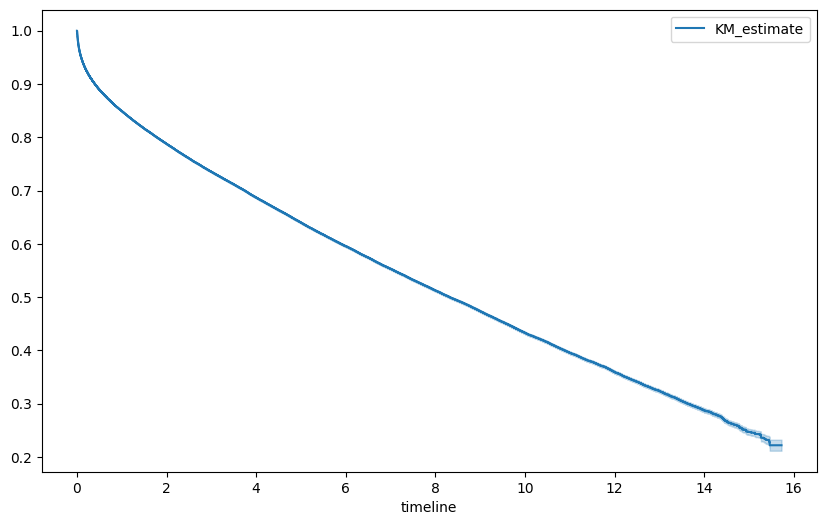

In [33]:
kmf_mimic = KaplanMeierFitter()
kmf_mimic.fit(durations=tab_data['timey'], event_observed=tab_data['death'])
plt.figure(figsize=(10, 6))
kmf_mimic.plot_survival_function()

In [34]:
pct_survival = kmf_mimic.survival_function_[(kmf_mimic.survival_function_.index <= 5.001) & (kmf_mimic.survival_function_.index >= 4.999)].values[0][0]
print(f'Percentage survival at 5 years: {pct_survival*100:.2f}%')
print(f'Percentage mortality at 5 years: {(1-pct_survival)*100:.2f}%')

Percentage survival at 5 years: 63.99%
Percentage mortality at 5 years: 36.01%


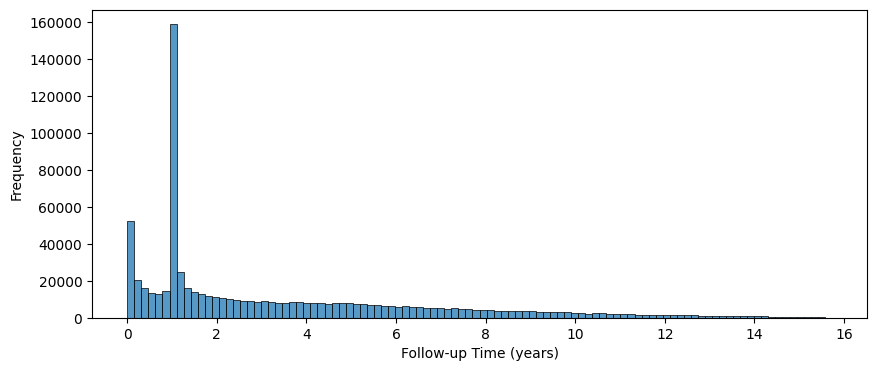

In [8]:
# plot distribution of timey
plt.figure(figsize=(10, 4))
sns.histplot(tab_data['timey'], bins=100, kde=False)
# plt.title('Distribution of Follow-up Time (timey)')
plt.xlabel('Follow-up Time (years)')
plt.ylabel('Frequency')
plt.show()

In [9]:
# loading the xlstm model
import utils.utils as utils
from models.classification import xLSTMClassification

# embedding_size: 1024
# encoder_type: vanilla
# xlstm_config: ["s","s","m","m","s", "s","m","m","s"]
# checkpoint: pretrain-xLSTM/0rgc8fun/checkpoints/epoch=49-step=504700.ckpt
# use_final_layer_norm: false
# cls_normalization: null

config = utils.parse_config('configs/train_mortality_run_config.yaml', 'config_defaults/train_mortality_config_defaults.yaml')
config.embedding_size = 1024
config.encoder_type = 'vanilla'
config.xlstm_config = ["s","s","m","m","s","s","m","m","s"]
config.checkpoint = 'train-mortality/hq0hw9ne/checkpoints/epoch=11-step=4308.ckpt'
config.num_workers = 32
config.drop_path_prob = 0.

# load mortality default config
model = utils.get_base_model(config)

/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


using linear patch embedding
creating xlstm with slstm at:  [0, 1, 4, 5, 8]
{'verbose': True, 'with_cuda': True, 'extra_ldflags': ['-L/usr/local/cuda-12.6/lib', '-lcublas'], 'extra_cflags': ['-DSLSTM_HIDDEN_SIZE=1024', '-DSLSTM_BATCH_SIZE=512', '-DSLSTM_NUM_HEADS=4', '-DSLSTM_NUM_STATES=4', '-DSLSTM_DTYPE_B=float', '-DSLSTM_DTYPE_R=__nv_bfloat16', '-DSLSTM_DTYPE_W=__nv_bfloat16', '-DSLSTM_DTYPE_G=__nv_bfloat16', '-DSLSTM_DTYPE_S=__nv_bfloat16', '-DSLSTM_DTYPE_A=float', '-DSLSTM_NUM_GATES=4', '-DSLSTM_SIMPLE_AGG=true', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL_VALID=false', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL=0.0', '-DSLSTM_FORWARD_CLIPVAL_VALID=false', '-DSLSTM_FORWARD_CLIPVAL=0.0', '-U__CUDA_NO_HALF_OPERATORS__', '-U__CUDA_NO_HALF_CONVERSIONS__', '-U__CUDA_NO_BFLOAT16_OPERATORS__', '-U__CUDA_NO_BFLOAT16_CONVERSIONS__', '-U__CUDA_NO_BFLOAT162_OPERATORS__', '-U__CUDA_NO_BFLOAT162_CONVERSIONS__'], 'extra_cuda_cflags': ['-Xptxas="-v"', '-gencode', 'arch=compute_80,code=compute_80', '-res-usage'

W0904 11:31:22.971000 55868 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0904 11:31:22.971000 55868 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/xlstm/blocks/slstm/cell.py:543: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @conditional_decorator(
/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/xlstm/blocks/slstm/cell.py:568: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @conditional_decorator(


ninja: no work to do.
{'verbose': True, 'with_cuda': True, 'extra_ldflags': ['-L/usr/local/cuda-12.6/lib', '-lcublas'], 'extra_cflags': ['-DSLSTM_HIDDEN_SIZE=1024', '-DSLSTM_BATCH_SIZE=512', '-DSLSTM_NUM_HEADS=4', '-DSLSTM_NUM_STATES=4', '-DSLSTM_DTYPE_B=float', '-DSLSTM_DTYPE_R=__nv_bfloat16', '-DSLSTM_DTYPE_W=__nv_bfloat16', '-DSLSTM_DTYPE_G=__nv_bfloat16', '-DSLSTM_DTYPE_S=__nv_bfloat16', '-DSLSTM_DTYPE_A=float', '-DSLSTM_NUM_GATES=4', '-DSLSTM_SIMPLE_AGG=true', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL_VALID=false', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL=0.0', '-DSLSTM_FORWARD_CLIPVAL_VALID=false', '-DSLSTM_FORWARD_CLIPVAL=0.0', '-U__CUDA_NO_HALF_OPERATORS__', '-U__CUDA_NO_HALF_CONVERSIONS__', '-U__CUDA_NO_BFLOAT16_OPERATORS__', '-U__CUDA_NO_BFLOAT16_CONVERSIONS__', '-U__CUDA_NO_BFLOAT162_OPERATORS__', '-U__CUDA_NO_BFLOAT162_CONVERSIONS__'], 'extra_cuda_cflags': ['-Xptxas="-v"', '-gencode', 'arch=compute_80,code=compute_80', '-res-usage', '--use_fast_math', '-O3', '-Xptxas -O3', '--extra-de

In [10]:
import dataset.mimic_iv as mimic
from torch.utils.data import DataLoader
from dataset.generic_utils import get_transforms
import dataset.generic_utils as generic_utils

test_dataset = mimic.ECGMIMICDataset(config, split='all', global_augmentations=get_transforms(config, split='test'), downstream_task='mortality')
test_dataloader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, collate_fn=generic_utils.make_collate_fn_task(config, ['death', 'timey']))


using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


/home/luna97/Research/MIT-BIH_ecg_arrhytmia/dataset/mimic_iv.py:88: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dat_ecg = pd.read_csv(machine_measurement_path)
/home/luna97/Research/MIT-BIH_ecg_arrhytmia/dataset/mimic_iv.py:133: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dat['timey'] = dat['timey'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))


   subject_id  study_id  cart_id          ecg_time_x           report_0  \
0    10000032  40689238  6848296 2180-07-23 08:44:00       Sinus rhythm   
1    10000032  44458630  6848296 2180-07-23 09:54:00       Sinus rhythm   
2    10000032  49036311  6376932 2180-08-06 09:07:00  Sinus tachycardia   
3    10000117  45090959  6214760 2181-03-04 17:14:00       Sinus rhythm   
4    10000117  48446569  6632385 2183-09-18 13:52:00       Sinus rhythm   

                            report_1                    report_2  \
0  Possible right atrial abnormality                         NaN   
1  Possible right atrial abnormality                         NaN   
2                                NaN  Normal ECG except for rate   
3                                NaN                  Normal ECG   
4                                NaN                         NaN   

         report_3 report_4 report_5  ... anchor_age anchor_year  \
0  Borderline ECG      NaN      NaN  ...         52        2180   
1  Bor

In [11]:
from tqdm import tqdm
import torch

def eval_model(model, dataloader):
    model.eval()
    model.to('cuda')
    outputs_list = []
    death_list = []
    timey_list = []
    for batch in tqdm(dataloader):
        inputs = batch['signals'].to('cuda')
        deaths = batch['death']
        timeys = batch['timey']
        with torch.no_grad():
            outputs = model(inputs)
            outputs_list.extend(outputs.flatten().cpu().numpy())
            death_list.extend(deaths.cpu().numpy())
            timey_list.extend(timeys.cpu().numpy())
        # process outputs
    return outputs_list, death_list, timey_list

In [12]:
outputs_list, death_list, timey_list = eval_model(model, test_dataloader)

100%|█████████▉| 1438/1439 [03:15<00:00,  7.69it/s]W0904 11:35:14.575000 55868 torch/_dynamo/convert_frame.py:1016] [6/8] torch._dynamo hit config.recompile_limit (8)
W0904 11:35:14.575000 55868 torch/_dynamo/convert_frame.py:1016] [6/8]    function: '_impl' (/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/xlstm/blocks/slstm/cell.py:760)
W0904 11:35:14.575000 55868 torch/_dynamo/convert_frame.py:1016] [6/8]    last reason: 6/7: ___check_obj_id(self.func, 96281885935648)             
W0904 11:35:14.575000 55868 torch/_dynamo/convert_frame.py:1016] [6/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0904 11:35:14.575000 55868 torch/_dynamo/convert_frame.py:1016] [6/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.
100%|██████████| 1439/1439 [03:17<00:00,  7.27it/s]


In [13]:
tab_data['risk'] = outputs_list
tab_data.head()

/tmp/ipykernel_55868/1297476189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tab_data['risk'] = outputs_list


,subject_id,study_id,cart_id,ecg_time_x,report_0,report_1,report_2,report_3,report_4,report_5,...,anchor_year,anchor_year_group,dod,index_x,max_ecg_time,index_y,max_disch_time,death,timey,risk
0,10000032,40689238,6848296,2180-07-23 08:44:00,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,...,2180,2014 - 2016,2180-09-09,0,2180-08-06 09:07:00,0.0,2180-08-07 17:50:00,True,0.131507,8.426252
1,10000032,44458630,6848296,2180-07-23 09:54:00,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,...,2180,2014 - 2016,2180-09-09,0,2180-08-06 09:07:00,0.0,2180-08-07 17:50:00,True,0.131507,6.329053
2,10000032,49036311,6376932,2180-08-06 09:07:00,Sinus tachycardia,NaN,Normal ECG except for rate,NaN,NaN,NaN,...,2180,2014 - 2016,2180-09-09,0,2180-08-06 09:07:00,0.0,2180-08-07 17:50:00,True,0.093151,11.207150
3,10000117,45090959,6214760,2181-03-04 17:14:00,Sinus rhythm,NaN,Normal ECG,NaN,NaN,NaN,...,2174,2008 - 2010,NaT,1,2183-09-18 13:52:00,4.0,2183-09-21 16:30:00,False,3.550685,-0.515460
4,10000117,48446569,6632385,2183-09-18 13:52:00,Sinus rhythm,NaN,NaN,NaN,NaN,NaN,...,2174,2008 - 2010,NaT,1,2183-09-18 13:52:00,4.0,2183-09-21 16:30:00,False,1.008219,4.388612


<Axes: >

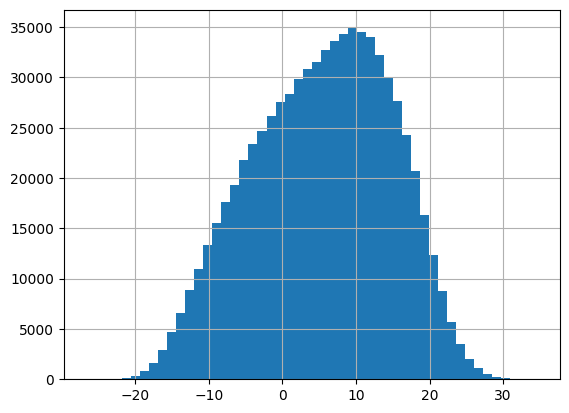

In [14]:
tab_data['risk'].hist(bins=50)

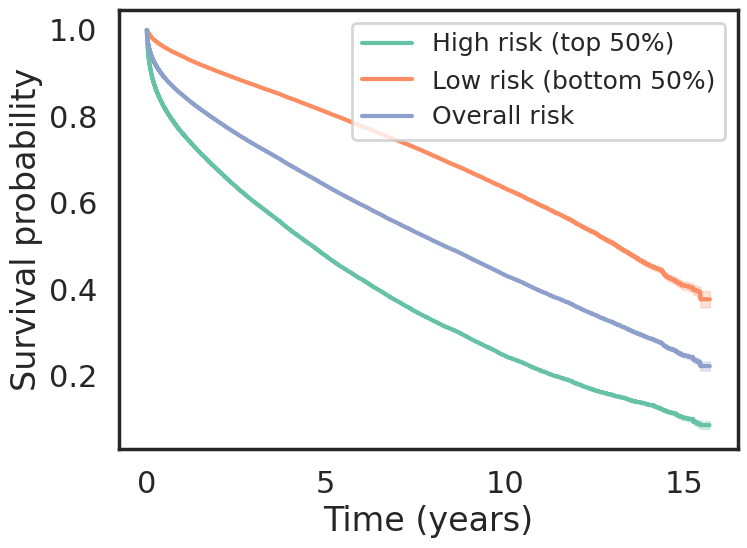

In [15]:
outputs = -np.array(outputs_list)
events = np.array(death_list)
times = np.array(timey_list)
median_risk = np.median(outputs)
high_mask = outputs >= median_risk
low_mask = outputs < median_risk

# Initialize KM fitter
kmf = KaplanMeierFitter()

plt.figure(figsize=(8, 6))

sns.set_style("white")
sns.set_context("poster")   # nicer font sizes for presentations
palette = sns.color_palette("Set2")  # e.g., pastel but distinct colors

# Low-risk KM curve
kmf.fit(tab_data[low_mask]['timey'], tab_data[low_mask]['death'], label="High risk (top 50%)")
ax = kmf.plot(ci_show=True, color=palette[0])

# High-risk KM curve
kmf.fit(tab_data[high_mask]['timey'], tab_data[high_mask]['death'], label="Low risk (bottom 50%)")
kmf.plot(ax=ax, ci_show=True, color=palette[1])

kmf.fit(tab_data['timey'], tab_data['death'], label="Overall risk")
kmf.plot(ax=ax, ci_show=True, color=palette[2])

# plt.title("Kaplan–Meier Curves by Predicted Risk Group")
plt.xlabel("Time (years)")
plt.ylabel("Survival probability")
plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/km_curve_mortality.pdf')

In [16]:
from lifelines import CoxPHFitter

tab_data_fitter = tab_data[['anchor_age', 'risk', 'timey', 'gender', 'death']].copy()
tab_data_fitter['gender'] = tab_data_fitter['gender'].map({'M': 1, 'F': 0})
tab_data_fitter['risk'] = tab_data_fitter['risk']
cph_raw = CoxPHFitter()
cph_raw.fit(tab_data_fitter, duration_col='timey', event_col='death')

<lifelines.CoxPHFitter: fitted with 736379 total observations, 490680 right-censored observations>

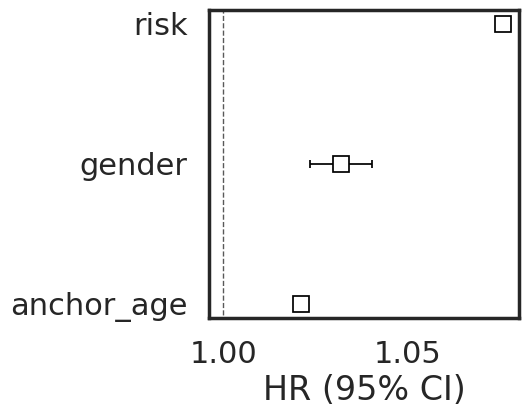

In [17]:
plt.figure(figsize=(4, 4))
sns.set_style("white")
sns.set_context("poster") 

cph_raw.plot(hazard_ratios=True)
plt.show()

<Figure size 600x600 with 0 Axes>

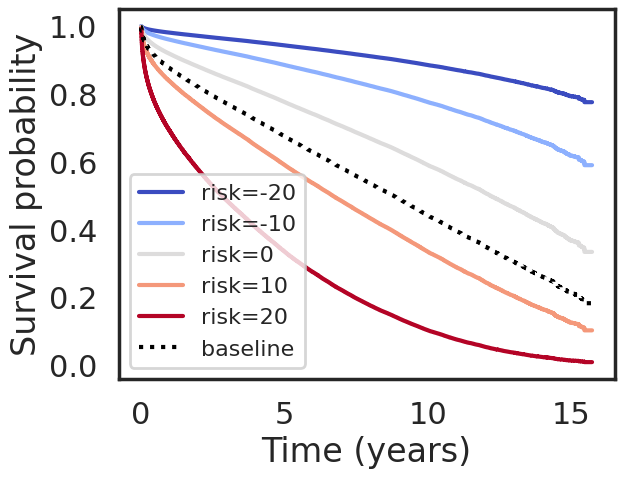

In [18]:
sns.set_style("white")
sns.set_context("poster")   # nicer font sizes for presentations

plt.figure(figsize=(6, 6))
cph_raw.plot_partial_effects_on_outcome(covariates='risk', values=[-20, -10, 0, 10, 20], cmap='coolwarm')

plt.xlabel("Time (years)")
plt.ylabel("Survival probability")
plt.legend(fontsize=16)
plt.savefig('figs/partial_effects_risk_disambiguated.pdf')


In [19]:

tab_data_fitter = tab_data[['anchor_age', 'risk', 'timey', 'gender', 'death']].copy()
tab_data_fitter['gender'] = tab_data_fitter['gender'].map({'M': 1, 'F': 0})
tab_data_fitter['risk'] = tab_data_fitter['risk'] > tab_data_fitter['risk'].median()
cph = CoxPHFitter()
cph.fit(tab_data_fitter, duration_col='timey', event_col='death')

<lifelines.CoxPHFitter: fitted with 736379 total observations, 490680 right-censored observations>

<Axes: xlabel='HR (95% CI)'>

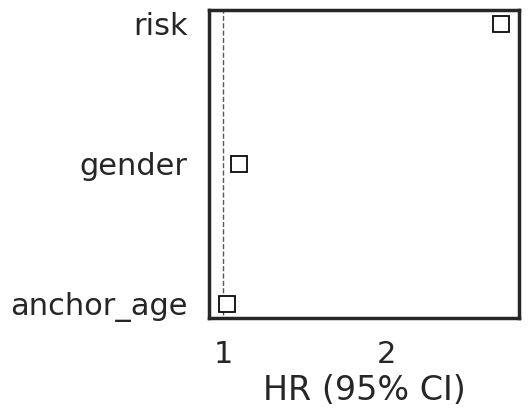

In [20]:
plt.figure(figsize=(4, 4))
cph.plot(hazard_ratios=True)


In [21]:
cph.hazard_ratios_

covariate
anchor_age    1.025831
risk          2.699091
gender        1.099317
Name: exp(coef), dtype: float64

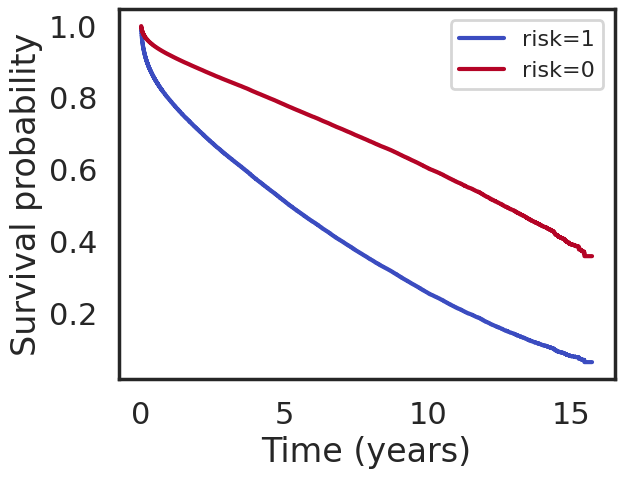

In [22]:
sns.set_style("white")
sns.set_context("poster")   # nicer font sizes for presentations


cph.plot_partial_effects_on_outcome(covariates='risk', values=[1, 0], cmap='coolwarm', plot_baseline=False)


plt.xlabel("Time (years)")
plt.ylabel("Survival probability")
plt.legend(fontsize=16)
plt.savefig('figs/partial_effects_risk_disambiguated.pdf')

In [23]:
# tab_data_fitter = tab_data.groupby('subject_id').agg('first')[['anchor_age', 'risk', 'timey', 'gender', 'death']].copy()
tab_data_fitter = tab_data[['anchor_age', 'risk', 'timey', 'gender', 'death']].copy()
tab_data_fitter['gender'] = tab_data_fitter['gender'].map({'M': 1, 'F': 0})
tab_data_fitter.rename(columns={'anchor_age': 'Age', 'gender': 'Gender'}, inplace=True)
tab_data_fitter['Low risk'] = tab_data_fitter['risk'] < tab_data_fitter['risk'].quantile(0.25)
tab_data_fitter['High risk'] = tab_data_fitter['risk'] > tab_data_fitter['risk'].quantile(0.75)
tab_data_fitter.drop(columns=['risk'], inplace=True)
cph = CoxPHFitter()
cph.fit(tab_data_fitter, duration_col='timey', event_col='death')

<lifelines.CoxPHFitter: fitted with 736379 total observations, 490680 right-censored observations>

In [24]:
tab_data_fitter

,Age,timey,Gender,death,Low risk,High risk
0,52,0.131507,0,True,False,False
1,52,0.131507,0,True,False,False
2,52,0.093151,0,True,False,False
3,48,3.550685,0,False,False,False
4,48,1.008219,0,False,False,False
...,...,...,...,...,...,...
799975,58,0.013699,1,True,False,True
799976,58,0.013699,1,True,False,False
799978,57,1.024658,0,False,False,False
799979,57,1.021918,0,False,False,False


<Figure size 600x400 with 0 Axes>

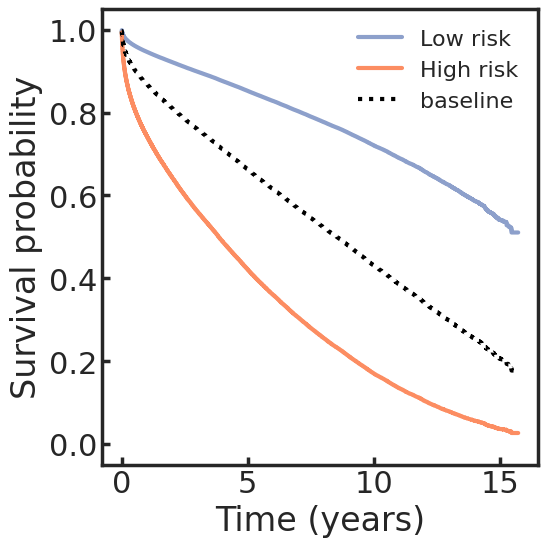

In [48]:
sns.set_style("white")
sns.set_context("poster")   # nicer font sizes for presentations

plt.figure(figsize=(6, 4))
cph.plot_partial_effects_on_outcome(covariates=['Low risk', 'High risk'], values=[[1, 0], [0, 1]], plot_baseline=True, figsize=(6, 6))

# set colors
plt.gca().lines[0].set_color(palette[2])  # Low risk
plt.gca().lines[1].set_color(palette[1])   # High risk

plt.xlabel("Time (years)")
plt.ylabel("Survival probability")

# change captions
plt.gca().lines[0].set_label('Low risk')
plt.gca().lines[1].set_label('High risk')

plt.legend(fontsize=16, frameon=False, loc='upper right')
plt.tick_params(axis='both', which='both', direction='in', bottom=True, left=True, length=6)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('figs/partial_effects_risk_disambiguated.svg')

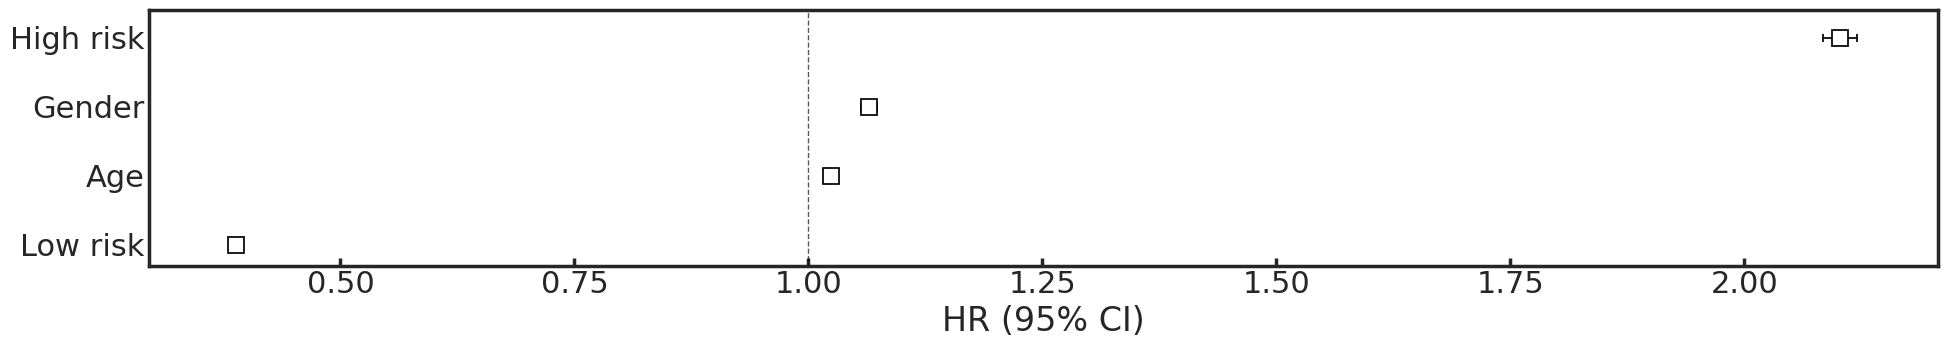

In [26]:
sns.set_style("white")
sns.set_context("poster")   # nicer font sizes for presentations


plt.figure(figsize=(20, 4))
ax = cph.plot(hazard_ratios=True)
# plt.xlim(0.01, 2.6)
# for line in ax.get_lines():
#     line.set_marker('^')  # Change 'o' to any matplotlib marker style, e.g. 's', '^', 'D'
#     line.set_markersize(1)  # Change the size of the markers
plt.ylim(-0.3, 3.4)

plt.tick_params(axis='both', which='both', direction='in', bottom=True, length=6)

plt.tight_layout()
plt.savefig('figs/hazard_ratios_disambiguated.svg')

In [27]:
cph.hazard_ratios_ 

covariate
Age          1.023653
Gender       1.064798
Low risk     0.388580
High risk    2.102277
Name: exp(coef), dtype: float64

In [28]:
cph.confidence_intervals_

,95% lower-bound,95% upper-bound
covariate,,
Age,0.023069,0.023686
Gender,0.054759,0.070812
Low risk,-0.960514,-0.929999
High risk,0.734545,0.751498


In [29]:
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
Age,0.023378,1.023653,0.000157,0.023069,0.023686,1.023337,1.023969,0.0,148.470542,0.000000e+00,inf
Gender,0.062785,1.064798,0.004095,0.054759,0.070812,1.056286,1.073379,0.0,15.330953,4.749670e-53,173.814362
Low risk,-0.945256,0.388580,0.007785,-0.960514,-0.929999,0.382696,0.394554,0.0,-121.425507,0.000000e+00,inf
High risk,0.743021,2.102277,0.004325,0.734545,0.751498,2.084533,2.120173,0.0,171.803791,0.000000e+00,inf


In [30]:
# get concordance index
cph.concordance_index_

np.float64(0.7046294197993302)